# Lista de Exercícios EXTRA – Pré-processamento e Agrupamento

**Disciplina:** Inteligência Artificial
**Prof.** Gabriel Pereira de Oliveira
**Aluno** João Comini César de Andrade

Este notebook contém as soluções das Questões 1 e 2 da Lista de Exercícios EXTRA,
utilizando o conjunto de dados **Credit Card Fraud Detection**
(https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud).

O dataset original contém 284.807 transações realizadas por clientes europeus em
setembro de 2013, sendo 492 fraudes (0,172%), o que caracteriza um forte
desbalanceamento entre as classes. As variáveis `V1` a `V28` são componentes obtidos
por PCA (para preservar a confidencialidade), `Time` é o tempo em segundos desde a
primeira transação e `Amount` é o valor da transação. `Class` indica se a transação
é fraude (1) ou não (0).

A mesma semente aleatória (`RANDOM_STATE = 42`) é utilizada em todas as etapas do
notebook para garantir a reprodutibilidade dos resultados.

> **Observação sobre o arquivo de dados:** este notebook foi executado com o arquivo
> real `creditcard.csv` (284.807 transações), baixado do dataset
> *Credit Card Fraud Detection* do Kaggle, colocado na mesma pasta do notebook. Como
> medida de segurança, caso esse arquivo não esteja presente, o notebook gera
> automaticamente um pequeno conjunto de dados sintético com a mesma estrutura de
> colunas (`Time`, `V1`...`V28`, `Amount`, `Class`) apenas para que todas as células
> continuem executando sem erro.


In [1]:
# Importação das bibliotecas utilizadas em todo o notebook
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report, recall_score, precision_score, f1_score
)
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score

# Semente aleatória fixa, utilizada em TODAS as etapas do notebook
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


## Carregamento dos dados

Caso o arquivo `creditcard.csv` (disponível no Kaggle) esteja presente na mesma pasta
deste notebook, ele será utilizado. Caso contrário, geramos um conjunto de dados
sintético com a mesma estrutura (30 colunas de entrada + `Class`) e a mesma proporção
extrema entre classes, apenas para fins de demonstração do pipeline.

In [2]:
DATA_PATH = "creditcard.csv"

if os.path.exists(DATA_PATH):
    df = pd.read_csv(DATA_PATH)
    print("Arquivo creditcard.csv carregado com sucesso.")
else:
    print("Arquivo creditcard.csv não encontrado - gerando dados sintéticos para demonstração.")
    rng = np.random.RandomState(RANDOM_STATE)
    n = 8000
    n_fraud = 14

    data = {"Time": rng.randint(0, 172792, size=n).astype(float)}
    for i in range(1, 29):
        data[f"V{i}"] = rng.normal(0, 1, size=n)
    data["Amount"] = np.round(np.abs(rng.lognormal(mean=3, sigma=1.5, size=n)), 2)
    data["Class"] = 0

    df = pd.DataFrame(data)
    fraud_idx = rng.choice(n, size=n_fraud, replace=False)
    df.loc[fraud_idx, "Class"] = 1
    for i in [3, 4, 10, 11, 12, 14, 17]:
        df.loc[fraud_idx, f"V{i}"] += rng.normal(-4, 1, size=n_fraud)

    # acrescenta algumas duplicatas propositalmente, para a etapa 3
    df = pd.concat([df, df.sample(5, random_state=RANDOM_STATE)], ignore_index=True)

df.shape


Arquivo creditcard.csv carregado com sucesso.


(284807, 31)

## Questão 01 - Pipeline de classificação para detecção de fraude

### Escolha do modelo

Optamos pelo **Random Forest Classifier** como modelo de classificação. Justificativa:

- É um modelo robusto a *outliers* e a atributos em escalas diferentes;
- Lida bem com problemas não lineares e interações entre variáveis (importante, já que
  `V1`-`V28` são componentes de PCA sem significado direto);
- Permite o uso do parâmetro `class_weight`/oversampling para lidar com classes
  desbalanceadas;
- Foi um dos modelos discutidos em aula e oferece um bom equilíbrio entre desempenho e
  interpretabilidade (importância das variáveis).

O mesmo modelo (`RandomForestClassifier`) e a mesma semente (`RANDOM_STATE = 42`) serão
mantidos em todas as comparações realizadas neste notebook.

### 1. Análise exploratória

In [3]:
print("Dimensões do dataset:", df.shape)
df.head()


Dimensões do dataset: (284807, 31)


   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10       V11       V12       V13       V14  \
0  0.098698  0.363787  0.090794 -0.551600 -0.617801 -0.991390 -0.311169   
1  0.085102 -0.255425 -0.166974  1.612727  1.065235  0.489095 -0.143772   
2  0.247676 -1.514654  0.207643  0.624501  0.066084  0.717293 -0.165946   
3  0.377436 -1.387024 -0.054952 -0.226487  0.178228  0.507757 -0.287924   
4 -0.270533  0.817739  0.753074 -0.822843  0.538196  1.345852 -1.119670   

        V15       V16       V17       V18       V19       V20 

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

In [5]:
df.describe().T


           count          mean           std         min           25%  \
Time    284807.0  9.481386e+04  47488.145955    0.000000  54201.500000   
V1      284807.0  1.175161e-15      1.958696  -56.407510     -0.920373   
V2      284807.0  3.384974e-16      1.651309  -72.715728     -0.598550   
V3      284807.0 -1.379537e-15      1.516255  -48.325589     -0.890365   
V4      284807.0  2.094852e-15      1.415869   -5.683171     -0.848640   
V5      284807.0  1.021879e-15      1.380247 -113.743307     -0.691597   
V6      284807.0  1.494498e-15      1.332271  -26.160506     -0.768296   
V7      284807.0 -5.620335e-16      1.237094  -43.557242     -0.554076   
V8      284807.0  1.149614e-16      1.194353  -73.216718     -0.208630   
V9      284807.0 -2.414189e-15      1.098632  -13.434066     -0.643098   
V10     284807.0  2.238554e-15      1.088850  -24.588262     -0.535426   
V11     284807.0  1.724421e-15      1.020713   -4.797473     -0.762494   
V12     284807.0 -1.245415e-15      0.

Class
0    284315
1       492
Name: count, dtype: int64
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


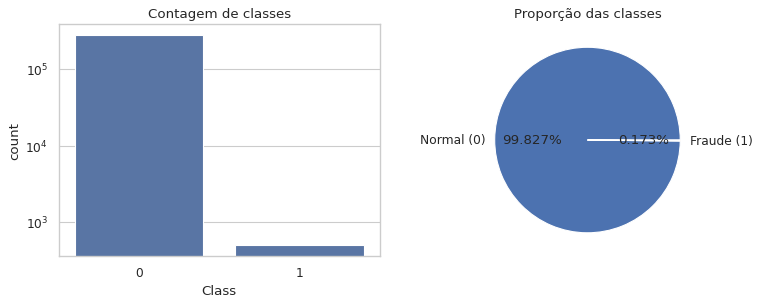

In [6]:
# Proporção das classes (0 = normal, 1 = fraude)
class_counts = df["Class"].value_counts()
class_pct = df["Class"].value_counts(normalize=True) * 100

print(class_counts)
print(class_pct)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
sns.countplot(x="Class", data=df, ax=ax[0])
ax[0].set_title("Contagem de classes")
ax[0].set_yscale("log")

ax[1].pie(class_counts, labels=["Normal (0)", "Fraude (1)"], autopct="%.3f%%")
ax[1].set_title("Proporção das classes")
plt.tight_layout()
plt.show()


count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64


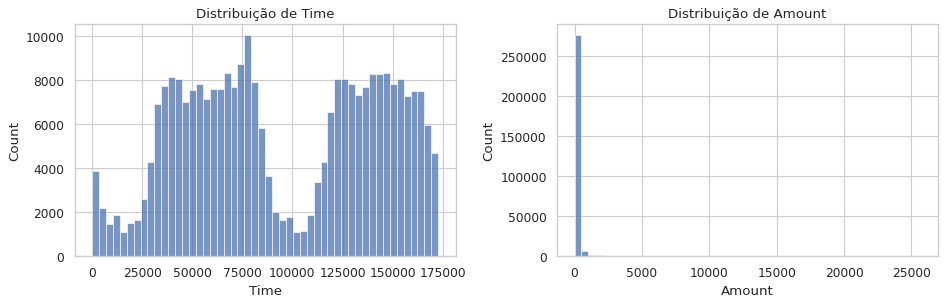

In [7]:
# Distribuição de Time e Amount
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df["Time"], bins=50, ax=ax[0])
ax[0].set_title("Distribuição de Time")

sns.histplot(df["Amount"], bins=50, ax=ax[1])
ax[1].set_title("Distribuição de Amount")
plt.tight_layout()
plt.show()

print(df["Amount"].describe())


**Comentários sobre a análise exploratória:**

- O dataset é composto por 30 atributos de entrada (`Time`, `V1`-`V28`, `Amount`) e o
  rótulo `Class`. Todos os atributos são numéricos (`float64`/`int64`).
- A variável `Class` apresenta forte desbalanceamento: a classe de fraude (1)
  representa uma fração muito pequena do total de transações, evidenciando que
  **métricas como acurácia não são adequadas** para avaliar o modelo nesse cenário.
- `Amount` apresenta distribuição assimétrica à direita (poucas transações de valor
  muito alto), enquanto `Time` representa o tempo (em segundos) desde a primeira
  transação, com distribuição relativamente uniforme ao longo dos dois dias de
  coleta.
- As variáveis `V1`-`V28`, por serem componentes de PCA, tendem a ter média próxima de
  zero e variância unitária (ou próxima disso), diferentemente de `Time` e `Amount`,
  que estão em escalas bem distintas.

### 2. Valores ausentes

In [8]:
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100

missing_summary = pd.DataFrame({"valores_ausentes": missing, "percentual (%)": missing_pct})
missing_summary[missing_summary["valores_ausentes"] > 0]


Empty DataFrame
Columns: [valores_ausentes, percentual (%)]
Index: []

In [9]:
print("Total de valores ausentes no dataset:", df.isnull().sum().sum())


Total de valores ausentes no dataset: 0


**Tratamento de valores ausentes:** o conjunto de dados não apresenta valores
ausentes em nenhuma das colunas (`Time`, `V1`-`V28`, `Amount`, `Class`). Portanto, esta
etapa não exige nenhum tratamento (imputação, remoção de linhas/colunas, etc.). Caso
existissem valores ausentes em atributos numéricos como `Amount` ou `Time`, uma
abordagem comum seria a imputação pela mediana (mais robusta a outliers) calculada
**apenas no conjunto de treino**, para evitar vazamento de informação (*data
leakage*) para o conjunto de teste.

### 3. Redundância e inconsistência (registros duplicados)

In [10]:
n_duplicados = df.duplicated().sum()
print(f"Número de registros duplicados: {n_duplicados}")

df = df.drop_duplicates().reset_index(drop=True)
print(f"Dimensões após remoção de duplicados: {df.shape}")


Número de registros duplicados: 1081
Dimensões após remoção de duplicados: (283726, 31)


In [11]:
# Verificação de inconsistências básicas (valores negativos onde não fazem sentido)
print("Valores de Time negativos:", (df["Time"] < 0).sum())
print("Valores de Amount negativos:", (df["Amount"] < 0).sum())
print("Valores de Class fora de {0,1}:", (~df["Class"].isin([0, 1])).sum())


Valores de Time negativos: 0
Valores de Amount negativos: 0
Valores de Class fora de {0,1}: 0


**Comentário:** registros duplicados foram identificados e removidos, pois
representam informação redundante que pode enviesar tanto a análise estatística
quanto o treinamento do modelo (por exemplo, fazendo com que o mesmo exemplo apareça
tanto no treino quanto no teste, caso a divisão seja feita após a remoção). Também
verificamos que não há inconsistências evidentes, como valores negativos em `Time`
ou `Amount`, ou valores fora do conjunto `{0, 1}` em `Class`.

### 4. Análise de correlação e multicolinearidade

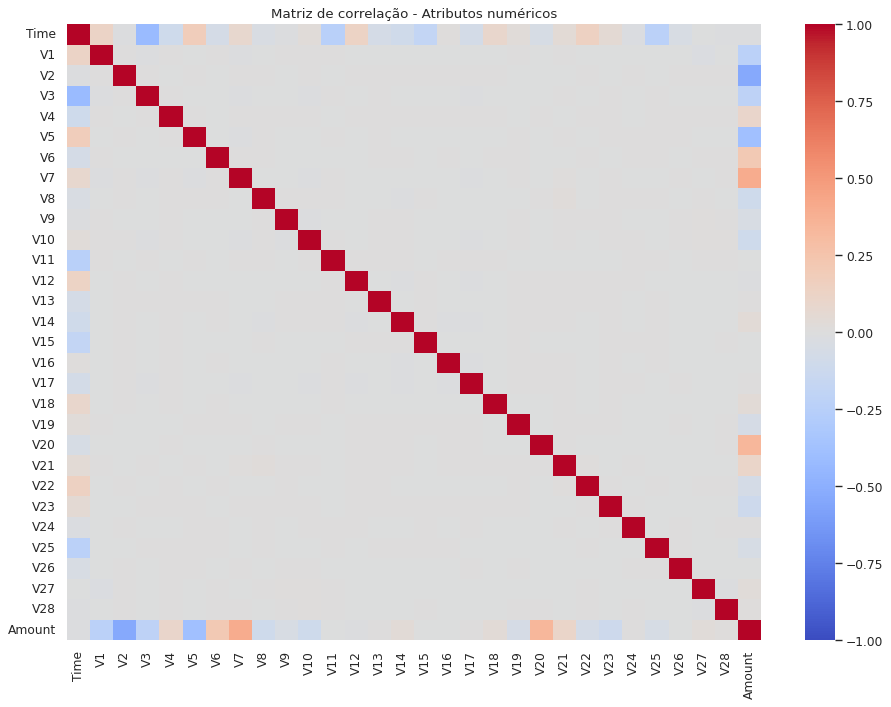

In [12]:
corr = df.drop(columns=["Class"]).corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Matriz de correlação - Atributos numéricos")
plt.show()


In [13]:
# Correlação média (em módulo) apenas entre os componentes de PCA V1-V28
v_cols = [f"V{i}" for i in range(1, 29)]
corr_v = df[v_cols].corr()

# remove a diagonal principal antes de calcular a média
corr_v_no_diag = corr_v.where(~np.eye(len(corr_v), dtype=bool))
print("Correlação média (absoluta) entre V1-V28:", corr_v_no_diag.abs().mean().mean())
print("Correlação máxima (absoluta) entre V1-V28:", corr_v_no_diag.abs().max().max())


Correlação média (absoluta) entre V1-V28: 0.0022958205618764894
Correlação máxima (absoluta) entre V1-V28: 0.018892285715434554


In [14]:
# Correlação de Time e Amount com as demais variáveis
corr_time_amount = corr[["Time", "Amount"]].drop(["Time", "Amount"])
corr_time_amount.sort_values(by="Amount", ascending=False).head(10)


         Time    Amount
V7   0.085335  0.400408
V20 -0.051022  0.340729
V6  -0.063279  0.216389
V21  0.045913  0.108058
V4  -0.105845  0.099514
V18  0.090305  0.035775
V14 -0.100316  0.034122
V27 -0.005171  0.027922
V28 -0.009305  0.010143
V17 -0.073819  0.007730

**Comentários sobre correlação e multicolinearidade:**

- Como esperado, as variáveis `V1` a `V28` são componentes principais obtidos por PCA
  e, portanto, **aproximadamente descorrelacionados entre si** - a correlação média
  (em módulo) entre elas é muito próxima de zero. A PCA é, por construção, uma
  transformação que produz componentes ortogonais (não correlacionados) quando
  aplicada sobre os dados originais, o que **reduz drasticamente o problema de
  multicolinearidade** entre essas variáveis.
- Já as variáveis `Time` e `Amount` **não fazem parte da transformação PCA** e podem
  apresentar correlações (em geral fracas) tanto entre si quanto com os componentes
  `V1`-`V28`.
- Como a multicolinearidade entre `V1`-`V28` já é, por construção, muito baixa, não há
  necessidade de remover atributos por esse motivo. Caso houvesse colunas fortemente
  correlacionadas (por exemplo, |correlação| > 0.9), poderíamos considerar removê-las
  para reduzir redundância, especialmente para modelos sensíveis a multicolinearidade
  (como regressão linear/logística sem regularização). Para o Random Forest, a
  multicolinearidade tem efeito limitado na performance, mas ainda pode afetar a
  interpretação da importância das variáveis.

### 5. Divisão treino-teste estratificada

A divisão é feita preservando a proporção de classes (`stratify=df["Class"]`), com 70%
dos dados para treino e 30% para teste. **Todas as etapas seguintes que aprendem
parâmetros (padronização, balanceamento, modelo) serão ajustadas apenas no conjunto de
treino.**

In [15]:
X = df.drop(columns=["Class"])
y = df["Class"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, " Teste:", X_test.shape)
print("\nProporção de classes - treino:")
print(y_train.value_counts(normalize=True))
print("\nProporção de classes - teste:")
print(y_test.value_counts(normalize=True))


Treino: (198608, 30)  Teste: (85118, 30)

Proporção de classes - treino:
Class
0    0.998333
1    0.001667
Name: proportion, dtype: float64

Proporção de classes - teste:
Class
0    0.998332
1    0.001668
Name: proportion, dtype: float64


### 6. Outliers

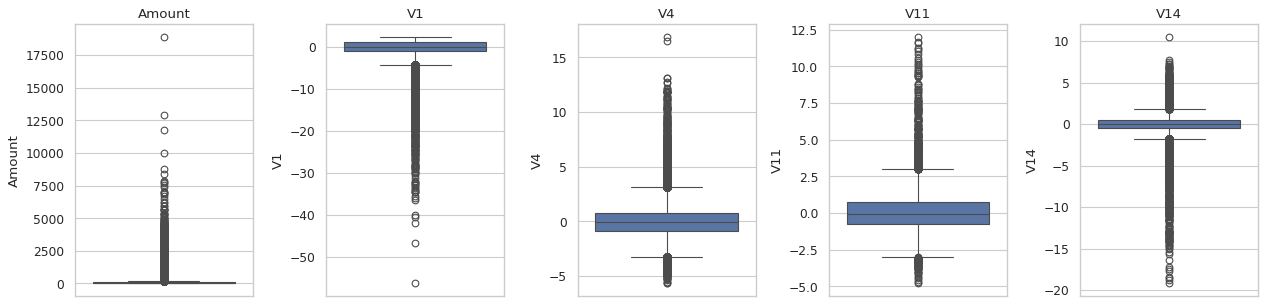

In [16]:
# Boxplots de algumas variáveis (Amount e alguns componentes V) - apenas no conjunto de treino
cols_to_plot = ["Amount", "V1", "V4", "V11", "V14"]

fig, axes = plt.subplots(1, len(cols_to_plot), figsize=(16, 4))
for ax, col in zip(axes, cols_to_plot):
    sns.boxplot(y=X_train[col], ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


In [17]:
# Quantidade de outliers (pelo critério de IQR) em cada coluna numérica, no conjunto de treino
def contar_outliers_iqr(serie):
    q1, q3 = serie.quantile(0.25), serie.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return ((serie < lower) | (serie > upper)).sum()

outlier_counts = X_train.apply(contar_outliers_iqr)
outlier_pct = (outlier_counts / len(X_train) * 100).round(2)

pd.DataFrame({"n_outliers": outlier_counts, "percentual (%)": outlier_pct}).sort_values(
    "n_outliers", ascending=False
).head(10)


        n_outliers  percentual (%)
V27          27159           13.67
Amount       22230           11.19
V28          20970           10.56
V20          19348            9.74
V8           16670            8.39
V6           16078            8.10
V23          12968            6.53
V12          10709            5.39
V21          10064            5.07
V14           9768            4.92

In [18]:
# Quantos outliers (em Amount, pelo critério de IQR) correspondem a transações fraudulentas?
q1, q3 = X_train["Amount"].quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
is_outlier_amount = (X_train["Amount"] < lower) | (X_train["Amount"] > upper)

print("Outliers em Amount:", is_outlier_amount.sum())
print("Desses, são fraude (Class=1):", y_train[is_outlier_amount].sum())
print("Proporção de fraudes entre os outliers de Amount:",
      y_train[is_outlier_amount].mean())
print("Proporção de fraudes no conjunto de treino como um todo:", y_train.mean())


Outliers em Amount: 22230
Desses, são fraude (Class=1): 60
Proporção de fraudes entre os outliers de Amount: 0.002699055330634278
Proporção de fraudes no conjunto de treino como um todo: 0.0016665995327479256


**Discussão - outliers devem ser removidos?**

A análise pelo critério de IQR mostra que diversas variáveis (incluindo `Amount` e
vários componentes `V1`-`V28`) possuem uma quantidade não trivial de "outliers" sob
esse critério estatístico. No entanto, **em problemas de detecção de fraude, a classe
minoritária (fraude) é justamente composta por eventos raros e atípicos** - ou seja, é
esperado que muitas transações fraudulentas se comportem como outliers em relação à
distribuição das transações normais (valores extremos em `Amount` ou nos componentes
de PCA).

Por esse motivo, **não removemos os outliers do conjunto de dados**. Removê-los
indiscriminadamente poderia eliminar justamente os exemplos da classe de interesse
(fraude), o que seria extremamente prejudicial para o objetivo do problema - detectar
fraudes. A abordagem adotada foi manter todos os registros e, em vez disso, lidar com o
desbalanceamento de classes na etapa de balanceamento (item 9), além de usar um modelo
(Random Forest) que é naturalmente robusto à presença de outliers.

### 7. Normalização/padronização

Aplicamos a padronização (`StandardScaler`, média 0 e desvio padrão 1) em todos os
atributos numéricos. O *scaler* é **ajustado (`fit`) apenas no conjunto de treino** e,
em seguida, aplicado (`transform`) tanto no treino quanto no teste, evitando vazamento
de informação do teste para o treino.

In [19]:
scaler = StandardScaler()

X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)

X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

X_train_scaled.describe().T[["mean", "std"]].head()


              mean       std
Time -6.239359e-17  1.000003
V1    3.148300e-18  1.000003
V2    5.008659e-18  1.000003
V3   -4.006928e-18  1.000003
V4   -1.302251e-17  1.000003

### 8. Codificação de variáveis categóricas

In [20]:
print(df.dtypes.value_counts())
print()
print(df.dtypes)


float64    30
int64       1
Name: count, dtype: int64

Time      float64
V1        float64
V2        float64
V3        float64
V4        float64
V5        float64
V6        float64
V7        float64
V8        float64
V9        float64
V10       float64
V11       float64
V12       float64
V13       float64
V14       float64
V15       float64
V16       float64
V17       float64
V18       float64
V19       float64
V20       float64
V21       float64
V22       float64
V23       float64
V24       float64
V25       float64
V26       float64
V27       float64
V28       float64
Amount    float64
Class       int64
dtype: object


**Esta etapa não se aplica ao conjunto de dados.** Todas as variáveis (`Time`,
`V1`-`V28`, `Amount` e `Class`) são numéricas (`float64` ou `int64`). Não há nenhuma
variável categórica (textual/nominal/ordinal) que precise ser codificada por meio de
técnicas como *One-Hot Encoding*, *Label Encoding* ou *Ordinal Encoding`. Por isso,
esta etapa de pré-processamento é desnecessária para este dataset.

### 9. Balanceamento de classe

O balanceamento é aplicado **apenas no conjunto de treino**. O conjunto de teste
permanece com a distribuição original (fortemente desbalanceada), simulando um
cenário real, onde o modelo é avaliado sobre dados com a mesma proporção de fraudes
observada na prática.

A técnica utilizada é o **oversampling aleatório da classe minoritária** (reamostragem
com reposição dos exemplos de fraude do treino, até igualar a quantidade de exemplos
da classe majoritária).

In [21]:
train_scaled = X_train_scaled.copy()
train_scaled["Class"] = y_train.values

majoritaria = train_scaled[train_scaled["Class"] == 0]
minoritaria = train_scaled[train_scaled["Class"] == 1]

print("Antes do balanceamento:")
print(train_scaled["Class"].value_counts())

minoritaria_oversampled = minoritaria.sample(
    n=len(majoritaria), replace=True, random_state=RANDOM_STATE
)

train_balanced = pd.concat([majoritaria, minoritaria_oversampled])
train_balanced = train_balanced.sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)

X_train_bal = train_balanced.drop(columns=["Class"])
y_train_bal = train_balanced["Class"]

print("\nDepois do balanceamento (apenas treino):")
print(y_train_bal.value_counts())

print("\nConjunto de teste (sem alteração):")
print(y_test.value_counts())


Antes do balanceamento:
Class
0    198277
1       331
Name: count, dtype: int64

Depois do balanceamento (apenas treino):
Class
0    198277
1    198277
Name: count, dtype: int64

Conjunto de teste (sem alteração):
Class
0    84976
1      142
Name: count, dtype: int64


## Treinamento e avaliação do modelo

Treinamos o `RandomForestClassifier` (com `random_state=RANDOM_STATE`) no conjunto de
treino balanceado e avaliamos no conjunto de teste original (desbalanceado).

Como a base é fortemente desbalanceada, **não utilizamos apenas a acurácia** como
métrica principal. Reportamos *recall*, *precision* e *F1-score* da classe minoritária
(fraude), além da matriz de confusão.

In [22]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

model.fit(X_train_bal, y_train_bal)
y_pred = model.predict(X_test_scaled)


In [23]:
print("Acurácia (apenas para referência - não é a métrica principal):")
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

print("\nRelatório de classificação:")
print(classification_report(y_test, y_pred, target_names=["Normal (0)", "Fraude (1)"]))

print("Recall (fraude):   ", recall_score(y_test, y_pred))
print("Precision (fraude):", precision_score(y_test, y_pred))
print("F1-score (fraude): ", f1_score(y_test, y_pred))


Acurácia (apenas para referência - não é a métrica principal):
0.9994948189572124

Relatório de classificação:
              precision    recall  f1-score   support

  Normal (0)       1.00      1.00      1.00     84976
  Fraude (1)       0.95      0.74      0.83       142

    accuracy                           1.00     85118
   macro avg       0.97      0.87      0.91     85118
weighted avg       1.00      1.00      1.00     85118

Recall (fraude):    0.7394366197183099
Precision (fraude): 0.9459459459459459
F1-score (fraude):  0.8300395256916996


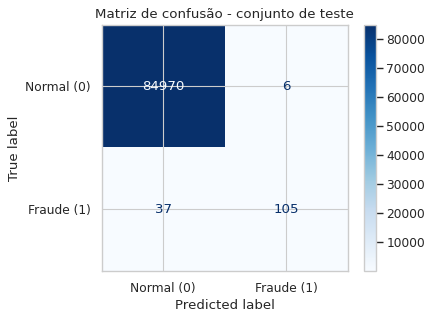

In [24]:
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Normal (0)", "Fraude (1)"]).plot(
    ax=ax, cmap="Blues", values_format="d"
)
plt.title("Matriz de confusão - conjunto de teste")
plt.show()


**Comentários sobre a avaliação:**

- A acurácia tende a ser muito alta (próxima de 100%) mesmo para um modelo "ingênuo"
  que classifique tudo como "normal", já que a classe de fraude representa uma fração
  muito pequena dos dados. Por isso, ela **não é informativa** sobre a capacidade do
  modelo de detectar fraudes.
- As métricas relevantes são *recall* (capacidade de identificar as fraudes
  existentes), *precision* (proporção das transações marcadas como fraude que
  realmente são fraude) e *F1-score* (média harmônica entre as duas), calculadas
  especificamente para a classe minoritária (fraude = 1).
- A matriz de confusão permite visualizar diretamente os falsos negativos (fraudes não
  detectadas) e falsos positivos (transações normais classificadas como fraude), que
  têm custos de negócio muito diferentes em um sistema real de detecção de fraude.

## Questão 02 - Agrupamento (K-Means e DBSCAN)

Nesta questão, aplicamos os algoritmos de agrupamento **K-Means** e **DBSCAN** sobre os
dados **sem o atributo `Class`** (o rótulo não é utilizado em agrupamento, apenas para
referência/visualização posterior, se desejado).

- Utilizamos uma **amostra de 10% do conjunto de treino** (já padronizado na Questão
  01), para reduzir o custo computacional.
- A mesma semente aleatória (`RANDOM_STATE = 42`) é utilizada na amostragem e nos
  algoritmos de agrupamento.

In [25]:
# Amostra de 10% do conjunto de treino padronizado (sem a coluna Class)
sample = X_train_scaled.sample(frac=0.10, random_state=RANDOM_STATE)
print("Dimensões da amostra utilizada no agrupamento:", sample.shape)


Dimensões da amostra utilizada no agrupamento: (19861, 30)


### K-Means - escolha do melhor k (método do cotovelo)

Variamos `k` entre 2 e 5, calculando a Soma dos Erros Quadráticos (SSE/inertia) e o
coeficiente de silhueta para cada valor de `k`.

In [26]:
k_values = range(2, 6)
sse_list = []
sil_list = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = kmeans.fit_predict(sample)
    sse_list.append(kmeans.inertia_)
    sil_list.append(silhouette_score(sample, labels))
    print(f"k={k} -> SSE={kmeans.inertia_:.2f}  |  Silhueta={sil_list[-1]:.4f}")


k=2 -> SSE=548776.65  |  Silhueta=0.0670
k=3 -> SSE=529954.06  |  Silhueta=0.0748
k=4 -> SSE=512147.56  |  Silhueta=0.0732
k=5 -> SSE=499914.99  |  Silhueta=0.0840


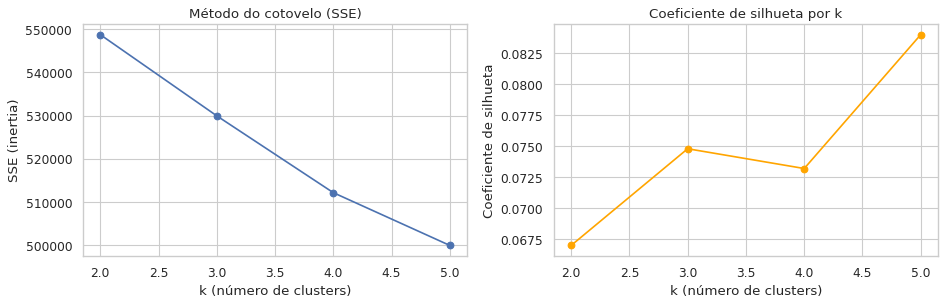

In [27]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].plot(list(k_values), sse_list, marker="o")
ax[0].set_xlabel("k (número de clusters)")
ax[0].set_ylabel("SSE (inertia)")
ax[0].set_title("Método do cotovelo (SSE)")

ax[1].plot(list(k_values), sil_list, marker="o", color="orange")
ax[1].set_xlabel("k (número de clusters)")
ax[1].set_ylabel("Coeficiente de silhueta")
ax[1].set_title("Coeficiente de silhueta por k")

plt.tight_layout()
plt.show()


In [28]:
# Seleciona o melhor k com base no maior coeficiente de silhueta entre 2 e 5
best_k = list(k_values)[int(np.argmax(sil_list))]
print("Melhor k (maior silhueta):", best_k)

kmeans_best = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
labels_kmeans = kmeans_best.fit_predict(sample)

print(f"K-Means com k={best_k}")
print("SSE:", kmeans_best.inertia_)
print("Coeficiente de silhueta:", silhouette_score(sample, labels_kmeans))
print("\nDistribuição dos pontos por cluster:")
print(pd.Series(labels_kmeans).value_counts().sort_index())


Melhor k (maior silhueta): 5
K-Means com k=5
SSE: 499914.99082869565
Coeficiente de silhueta: 0.08402021191653715

Distribuição dos pontos por cluster:
0    7890
1    1184
2     168
3    1379
4    9240
Name: count, dtype: int64


**Comentário (K-Means):** o método do cotovelo (SSE) mostra a redução do erro
quadrático conforme `k` aumenta - o SSE caiu de aproximadamente 548.777 (k=2) para
499.915 (k=5), uma redução suave e aproximadamente linear, sem um "cotovelo" muito
acentuado nesse intervalo. Esse comportamento é comum em dados de alta
dimensionalidade e com estrutura de cluster pouco definida (como é o caso de
componentes de PCA quase descorrelacionados, conforme já discutido na Questão 1).

Por isso, complementamos a análise com o coeficiente de silhueta: dentro do intervalo
avaliado (k de 2 a 5), o **maior coeficiente de silhueta foi obtido com k=5**
(silhueta ≈ 0,084), levemente superior aos demais valores (k=2: ≈0,067; k=3: ≈0,075;
k=4: ≈0,073). Os valores de silhueta são, no entanto, relativamente baixos em todos os
casos, indicando que os clusters formados pelo K-Means não são muito bem separados -
o que é esperado, já que os dados são compostos majoritariamente por componentes de
PCA quase descorrelacionados, sem uma estrutura natural de agrupamento muito forte.
Com k=5, o K-Means particionou a amostra em 5 grupos de tamanhos bastante distintos
(de 168 a 9.240 pontos), sugerindo a existência de alguns subgrupos pequenos e mais
específicos dentro dos dados, além de dois grandes grupos principais.

### DBSCAN

Aplicamos o DBSCAN com os **valores padrão** de `eps` (0.5) e `min_samples` (5) do
scikit-learn. Diferentemente do K-Means, o número de clusters não é definido a priori -
ele é descoberto automaticamente pelo algoritmo, que também identifica pontos
classificados como ruído/outliers (rótulo `-1`).

In [29]:
dbscan = DBSCAN()  # eps=0.5, min_samples=5 (valores padrão)
labels_dbscan = dbscan.fit_predict(sample)

n_clusters_dbscan = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise = int((labels_dbscan == -1).sum())

print("Número de clusters encontrados pelo DBSCAN:", n_clusters_dbscan)
print("Número de pontos classificados como ruído/outliers:", n_noise)
print("Percentual de outliers:", round(100 * n_noise / len(sample), 2), "%")


Número de clusters encontrados pelo DBSCAN: 69
Número de pontos classificados como ruído/outliers: 18924
Percentual de outliers: 95.28 %


In [30]:
# Métricas de qualidade do DBSCAN (calculadas apenas se houver mais de 1 cluster válido)
mask = labels_dbscan != -1

if n_clusters_dbscan > 1:
    sil_dbscan = silhouette_score(sample[mask], labels_dbscan[mask])
    print("Coeficiente de silhueta (excluindo outliers):", sil_dbscan)
else:
    print("Não foi possível calcular o coeficiente de silhueta: "
          "DBSCAN encontrou", n_clusters_dbscan,
          "cluster(s) válido(s) com os parâmetros padrão "
          "(eps=0.5, min_samples=5).")

# SSE (soma dos erros quadráticos) do DBSCAN: distância de cada ponto ao centróide
# do seu próprio cluster (não inclui os pontos classificados como ruído)
sse_dbscan = 0.0
for c in set(labels_dbscan):
    if c == -1:
        continue
    pts = sample[labels_dbscan == c]
    centro = pts.mean(axis=0)
    sse_dbscan += ((pts - centro) ** 2).to_numpy().sum()

print("SSE (DBSCAN, desconsiderando outliers):", sse_dbscan)


Coeficiente de silhueta (excluindo outliers): 0.5306572776473971
SSE (DBSCAN, desconsiderando outliers): 396.10901736505485


**Comentário (DBSCAN):** com os parâmetros padrão (`eps=0.5`, `min_samples=5`), o
DBSCAN encontrou **69 clusters** na amostra de 19.861 pontos, classificando **18.924
pontos (≈95,3%) como ruído/outliers** (rótulo -1) e apenas ≈4,7% dos pontos como
pertencentes a algum dos 69 clusters densos.

Esse resultado mostra que, em um espaço de ~30 dimensões padronizadas, o valor padrão
de `eps=0.5` é bastante restritivo: a maior parte dos pontos não possui ao menos
`min_samples=5` vizinhos dentro desse raio, sendo por isso marcada como ruído. Apenas
pequenos bolsões de pontos muito próximos entre si (provavelmente transações com
valores de `V1`-`V28` e `Amount` muito semelhantes) acabam formando os 69 clusters
densos identificados.

Em termos de qualidade, o coeficiente de silhueta calculado **apenas sobre os pontos
não classificados como ruído** foi de aproximadamente **0,53**, um valor
consideravelmente mais alto do que o obtido pelo K-Means (≈0,084). Isso indica que os
pequenos clusters densos encontrados pelo DBSCAN são internamente muito coesos e bem
separados entre si - mas representam apenas uma fração muito pequena (≈4,7%) do total
de dados, enquanto o K-Means particiona **100% dos pontos** em apenas 5 grupos bem
maiores e mais heterogêneos. A SSE do DBSCAN (≈396, calculada apenas sobre os pontos
não-ruído) também é muito menor que a do K-Means (≈499.915), o que é esperado, já que
o DBSCAN está descrevendo um número muito maior de clusters muito menores e mais
compactos.

### Comparação entre K-Means e DBSCAN - conclusões

- **K-Means** exige a definição prévia do número de clusters (`k`). Utilizando o
  método do cotovelo (SSE) em conjunto com o coeficiente de silhueta, o melhor valor
  encontrado no intervalo de 2 a 5 foi **k=5** (SSE ≈ 499.915, silhueta ≈ 0,084). O
  K-Means produz uma **partição completa** dos dados: todos os 19.861 pontos da amostra
  pertencem a algum dos 5 clusters (de tamanhos entre 168 e 9.240 pontos).
- **DBSCAN**, com os parâmetros padrão (`eps=0.5`, `min_samples=5`), não exige a
  definição do número de clusters, mas é fortemente dependente desses dois
  hiperparâmetros. Nos nossos dados (alta dimensionalidade, padronizados), os valores
  padrão resultaram em **69 clusters muito pequenos e densos**, cobrindo apenas
  ≈4,7% dos pontos, enquanto **≈95,3% dos pontos foram classificados como
  ruído/outliers**.
- Em termos de **qualidade interna** (coeficiente de silhueta), o DBSCAN apresentou um
  valor muito superior (≈0,53) ao do K-Means (≈0,084) - porém calculado sobre uma
  fração pequena e "fácil" dos dados (os pontos mais densos/próximos entre si). Já o
  K-Means apresenta uma silhueta mais modesta, mas descreve a totalidade dos dados em
  poucos grupos.
- De forma geral, esse exercício ilustra que **algoritmos baseados em densidade
  (DBSCAN) são muito sensíveis à escala e à dimensionalidade dos dados**. Com os
  parâmetros padrão, o DBSCAN tende a tratar a grande maioria das transações de cartão
  de crédito (que, após a padronização e por serem componentes de PCA, ficam
  relativamente "espalhadas" em um espaço de 30 dimensões) como ruído, conseguindo
  identificar apenas pequenos bolsões muito densos como clusters legítimos. O K-Means,
  por sua vez, sempre produz uma partição completa dos dados em `k` grupos, mas com uma
  separação entre clusters mais fraca neste conjunto de dados (silhuetas baixas em
  todo o intervalo testado), refletindo a baixa estrutura de agrupamento natural dos
  componentes de PCA quase descorrelacionados.
- Por fim, vale notar que **nenhum dos dois algoritmos de agrupamento utiliza o
  rótulo `Class`** - ou seja, eles não foram desenhados especificamente para separar
  transações fraudulentas de normais, mas sim para encontrar uma estrutura geral nos
  dados. Para detecção de fraude propriamente dita, o modelo supervisionado treinado
  na Questão 1 (Random Forest, com recall ≈0,74 e precisão ≈0,95 para a classe de
  fraude) é a abordagem mais adequada.